In [ ]:
!pip install tensorflow opencv-python matplotlib

In [ ]:
import zipfile

zip_path = '/content/data.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

print("✅ Extracted!")

✅ Extracted!


In [ ]:
import os

print(os.listdir('/content/dataset'))

['images']


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    '/content/dataset/images/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_data = train_datagen.flow_from_directory(
    '/content/dataset/images/val',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)


Found 192 images belonging to 2 classes.
Found 20 images belonging to 2 classes.


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
output = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.8385 - loss: 0.3455 - val_accuracy: 0.9500 - val_loss: 0.2433
Epoch 2/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.9583 - loss: 0.1276 - val_accuracy: 0.9500 - val_loss: 0.1157
Epoch 3/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.9844 - loss: 0.0534 - val_accuracy: 0.9500 - val_loss: 0.1394
Epoch 4/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.9844 - loss: 0.0328 - val_accuracy: 1.0000 - val_loss: 0.0771
Epoch 5/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.9948 - loss: 0.0191 - val_accuracy: 0.9500 - val_loss: 0.0860


In [ ]:
!pip install scikit-learn

In [ ]:
import numpy as np

# Get true labels
y_true = val_data.classes

# Predict probabilities
y_pred_probs = model.predict(val_data)

# Convert to binary (0/1)
y_pred = (y_pred_probs > 0.5).astype(int).reshape(-1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


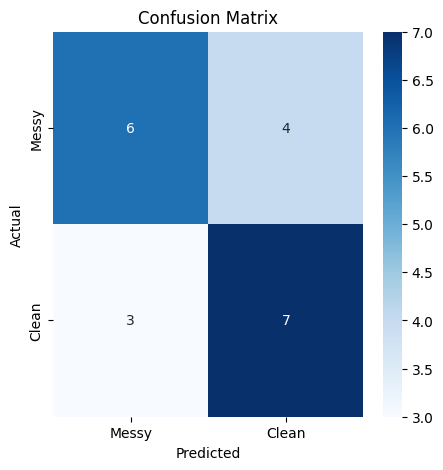

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Messy', 'Clean'],
            yticklabels=['Messy', 'Clean'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
model.save('/content/cleaning_model.h5')
print("✅ Model Saved!")

✅ Model Saved!


In [ ]:
import cv2
import numpy as np
import os
from tensorflow.keras.models import load_model

model = load_model('/content/cleaning_model.h5')

test_path = '/content/dataset/images/test'

def predict_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224,224))
    img = img / 255.0
    img = np.expand_dims(img, axis=0)

    pred = model.predict(img)[0][0]

    if pred > 0.5:
        return " CLEAN"
    else:
        return " NOT CLEAN"

# Loop through test images
for img_name in os.listdir(test_path):
    img_path = os.path.join(test_path, img_name)

    if img_name.endswith(('.png', '.jpg', '.jpeg')):
        result = predict_image(img_path)
        print(f"{img_name} → {result}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
2.png →  CLEAN
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
7.png →  CLEAN
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
4.png →  CLEAN
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
6.png →  NOT CLEAN
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
8.png →  CLEAN
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1.png →  NOT CLEAN
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
9.png →  NOT CLEAN
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
0.png →  NOT CLEAN
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
3.png →  NOT CLEAN
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
5.png →  CLEAN
